C:\Users\laank\AppData\Local\Temp\ipykernel_23148\281268996.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(csv_files))


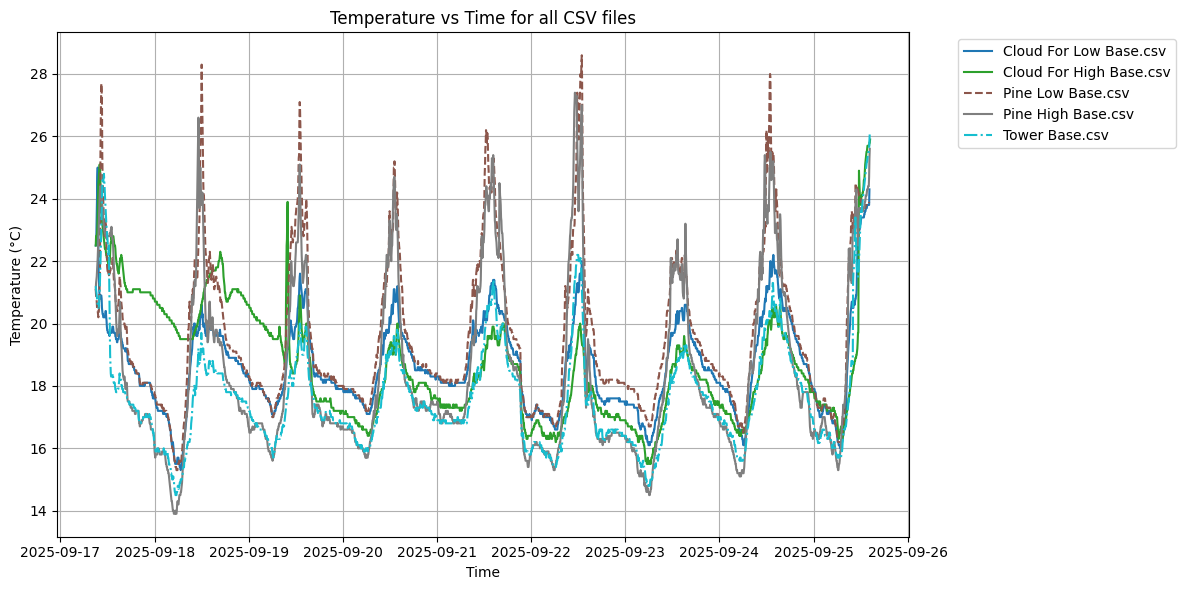

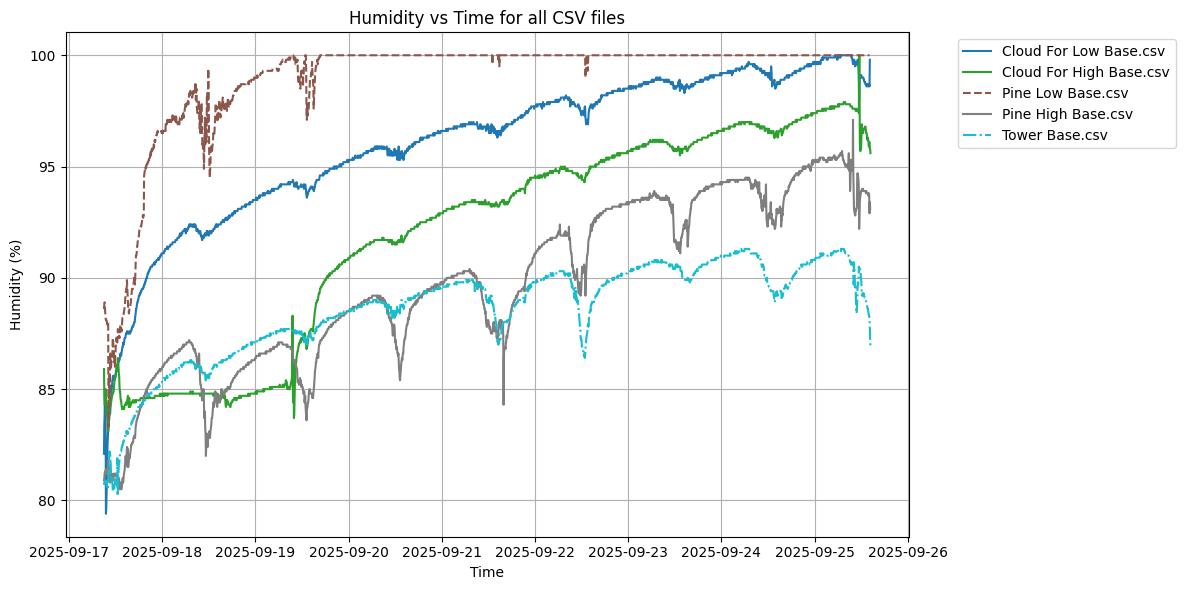

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob

csv_files = glob.glob("*.csv")

csv_files = ["Cloud For Low Base.csv", "Cloud For High Base.csv", "Pine Low Base.csv","Pine High Base.csv", "Tower Base.csv"]

colors = cm.get_cmap('tab10', len(csv_files))

special_styles = {
    2: '--', 
    4: '-.',   
    6: ':'     
}

# --- TEMPERATURE PLOT ---
plt.figure(figsize=(12,6))

for i, name in enumerate(csv_files):
    df = pd.read_csv(
        name, 
        sep=",", 
        decimal=".", 
        usecols=[0,1,2,3,4],  
        header=None,
        names=["ID", "Date", "Time", "Temp", "Humidity"]
    )
    
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce")
    
    style = special_styles.get(i, '-') 
    plt.plot(df["Datetime"], df["Temp"], label=name, color=colors(i), linestyle=style)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs Time for all CSV files")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()


# --- HUMIDITY PLOT ---
plt.figure(figsize=(12,6))

for i, name in enumerate(csv_files):
    df = pd.read_csv(
        name, 
        sep= ',',
        decimal=".", 
        usecols=[0,1,2,3,4],  
        header=None,
        names=["ID", "Date", "Time", "Temp", "Humidity"]
    )
    
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce")
    
    style = special_styles.get(i, '-') 
    plt.plot(df["Datetime"], df["Humidity"], label=name, color=colors(i), linestyle=style)

plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.title("Humidity vs Time for all CSV files")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()


C:\Users\laank\AppData\Local\Temp\ipykernel_23148\1590471931.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(csv_files))


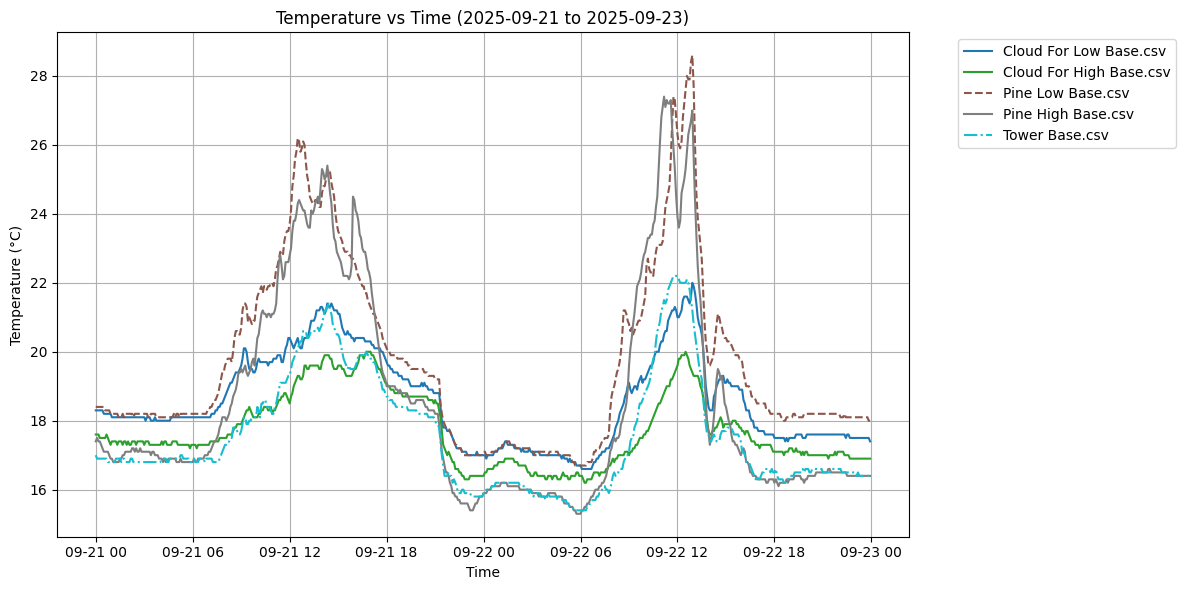

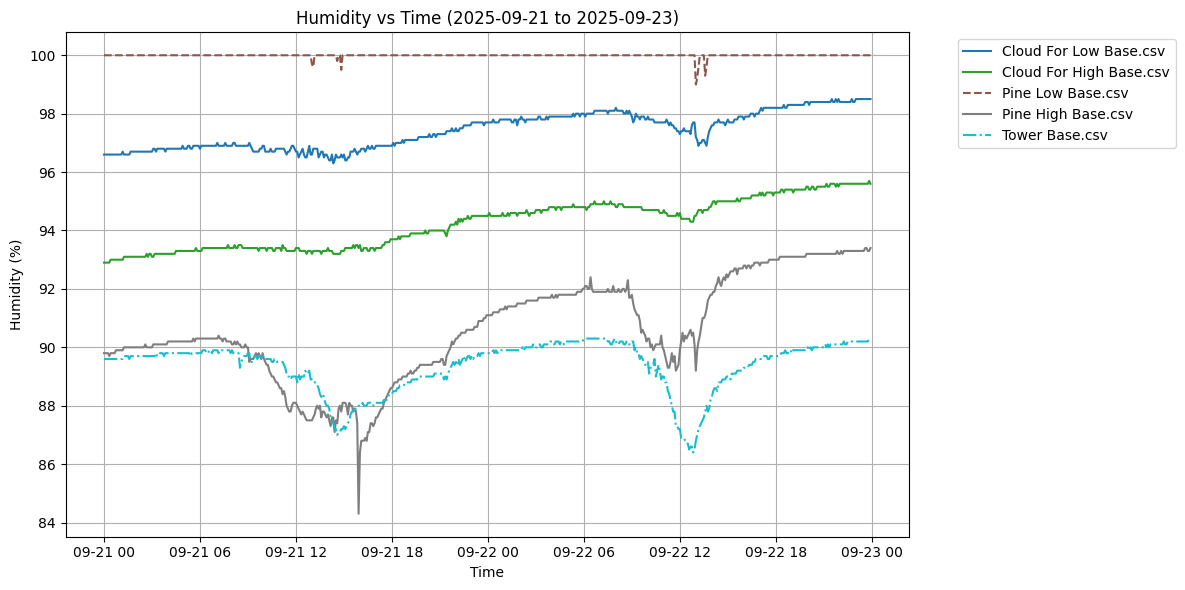

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob

csv_files = glob.glob("*.csv")

csv_files = ["Cloud For Low Base.csv", "Cloud For High Base.csv", 
             "Pine Low Base.csv", "Pine High Base.csv", "Tower Base.csv"]

colors = cm.get_cmap('tab10', len(csv_files))

special_styles = {
    2: '--', 
    4: '-.',   
    6: ':'     
}

# --- ✅ Set the date range here ---
start_date = pd.to_datetime("2025-09-21")
end_date   = pd.to_datetime("2025-09-23")  # same day, but can extend

# --- TEMPERATURE PLOT ---
plt.figure(figsize=(12,6))

for i, name in enumerate(csv_files):
    df = pd.read_csv(
        name, 
        sep=",", 
        decimal=".", 
        usecols=[0,1,2,3,4],  
        header=None,
        names=["ID", "Date", "Time", "Temp", "Humidity"]
    )
    
    df["Datetime"] = pd.to_datetime(
        df["Date"].astype(str) + " " + df["Time"].astype(str),
        errors="coerce"
    )
    
    # ✅ Filter within range
    df = df[(df["Datetime"] >= start_date) & (df["Datetime"] <= end_date)]
    
    style = special_styles.get(i, '-') 
    plt.plot(df["Datetime"], df["Temp"], label=name, color=colors(i), linestyle=style)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title(f"Temperature vs Time ({start_date.date()} to {end_date.date()})")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()


# --- HUMIDITY PLOT ---
plt.figure(figsize=(12,6))

for i, name in enumerate(csv_files):
    df = pd.read_csv(
        name, 
        sep=",",
        decimal=".", 
        usecols=[0,1,2,3,4],  
        header=None,
        names=["ID", "Date", "Time", "Temp", "Humidity"]
    )
    
    df["Datetime"] = pd.to_datetime(
        df["Date"].astype(str) + " " + df["Time"].astype(str),
        errors="coerce"
    )

    df = df[(df["Datetime"] >= start_date) & (df["Datetime"] <= end_date)]
    
    style = special_styles.get(i, '-') 
    plt.plot(df["Datetime"], df["Humidity"], label=name, color=colors(i), linestyle=style)

plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.title(f"Humidity vs Time ({start_date.date()} to {end_date.date()})")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()


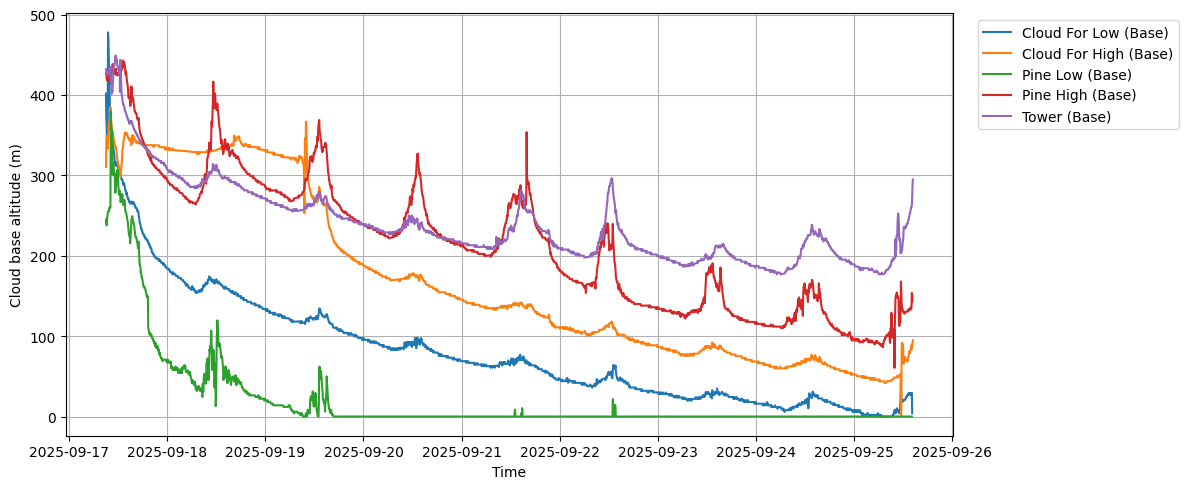

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# list your files
csv_files = ["Cloud For Low Base.csv", "Cloud For High Base.csv",
             "Pine Low Base.csv", "Pine High Base.csv", "Tower Base.csv"]

# set heights (m) for each file (edit to match your actual sensor heights)
sensor_heights = {
    "Cloud For Low Base.csv": 0.2,
    "Cloud For High Base.csv": 0.2,
    "Pine Low Base.csv": 0.2,
    "Pine High Base.csv": 0.2,
    "Tower Base.csv": 0.2
}

# nice labels for legend
labels = {
    "Cloud For Low Base.csv": "Cloud For Low (Base)",
    "Cloud For High Base.csv": "Cloud For High (Base)",
    "Pine Low Base.csv": "Pine Low (Base)",
    "Pine High Base.csv": "Pine High (Base)",
    "Tower Base.csv": "Tower (Base)"
}

def dewpoint_magnus(T, RH):
    """Magnus approximation. T in °C, RH in % -> Td in °C"""
    a = 17.27
    b = 237.7  # °C
    alpha = (a * T) / (b + T) + np.log(np.clip(RH, 0.1, 100) / 100.0)
    Td = (b * alpha) / (a - alpha)
    return Td

def compute_lcl_height(T, RH):
    """Return LCL above sensor in meters using LCL ≈ 125*(T - Td)."""
    Td = dewpoint_magnus(T, RH)
    lcl_m = 125.0 * (T - Td)
    return lcl_m, Td

# example: compute time series of cloud base (altitude) for each file
results = {}
for fname in csv_files:
    df = pd.read_csv(fname, sep=",", decimal=".", header=None,
                     usecols=[0,1,2,3,4],
                     names=["ID", "Date", "Time", "Temp", "Humidity"])
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce")
    df = df.dropna(subset=["Datetime", "Temp", "Humidity"]).reset_index(drop=True)

    df["Td"] = dewpoint_magnus(df["Temp"].values, df["Humidity"].values)
    df["LCL_m"] = 125.0 * (df["Temp"] - df["Td"])
    df["CloudBase_alt_m"] = sensor_heights.get(fname, 0.0) + df["LCL_m"]

    results[fname] = df

# quick plot of cloud base altitudes
plt.figure(figsize=(12,5))
for i, (fname, df) in enumerate(results.items()):
    plt.plot(df["Datetime"], df["CloudBase_alt_m"], label=labels.get(fname, fname))
plt.ylabel("Cloud base altitude (m)")
plt.xlabel("Time")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\laank\AppData\Local\Temp\ipykernel_23148\84265238.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(csv_files))


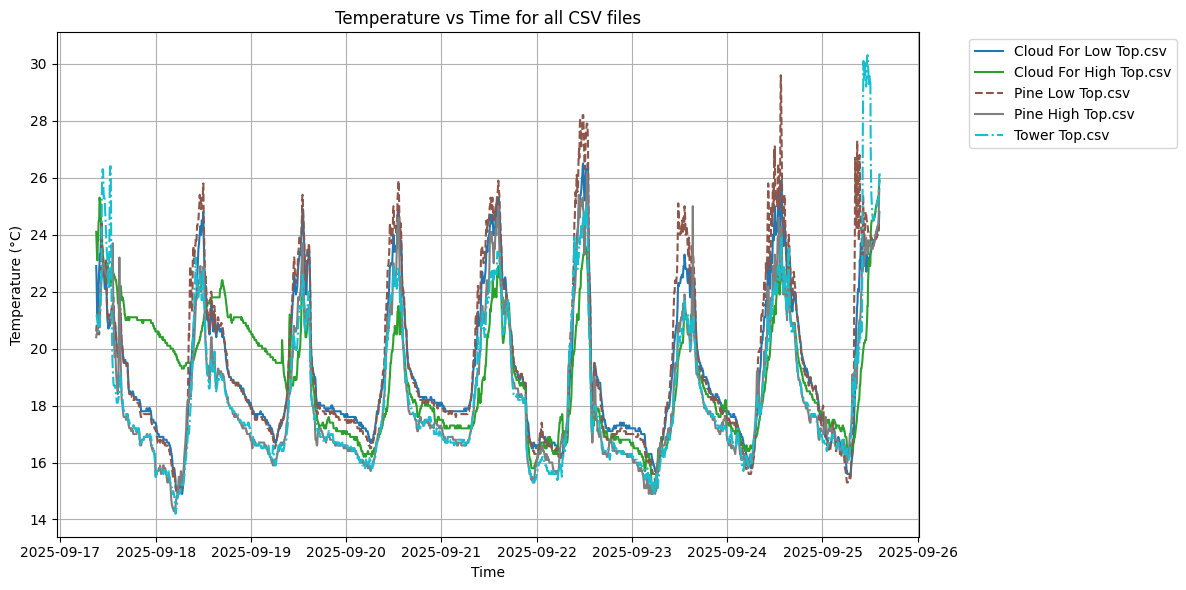

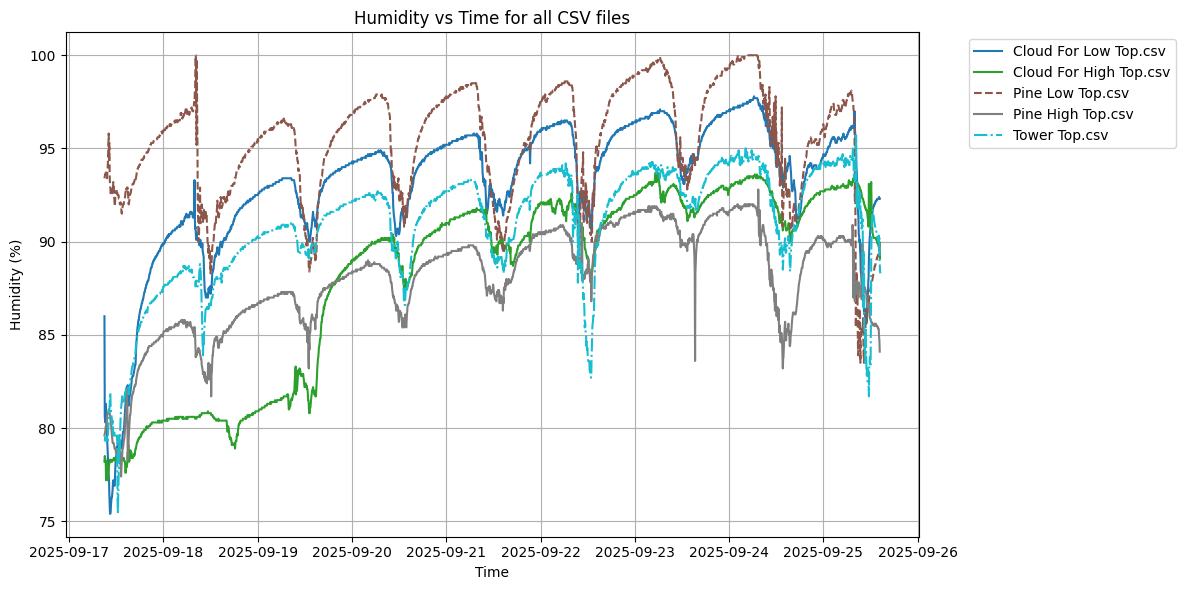

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob

csv_files = glob.glob("*.csv")

csv_files = ["Cloud For Low Top.csv", "Cloud For High Top.csv", "Pine Low Top.csv","Pine High Top.csv", "Tower Top.csv"]

colors = cm.get_cmap('tab10', len(csv_files))

special_styles = {
    2: '--', 
    4: '-.',   
    6: ':'     
}

# --- TEMPERATURE PLOT ---
plt.figure(figsize=(12,6))

for i, name in enumerate(csv_files):
    df = pd.read_csv(
        name, 
        sep=",", 
        decimal=".", 
        usecols=[0,1,2,3,4],  
        header=None,
        names=["ID", "Date", "Time", "Temp", "Humidity"]
    )
    
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce")
    
    style = special_styles.get(i, '-') 
    plt.plot(df["Datetime"], df["Temp"], label=name, color=colors(i), linestyle=style)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs Time for all CSV files")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()


# --- HUMIDITY PLOT ---
plt.figure(figsize=(12,6))

for i, name in enumerate(csv_files):
    df = pd.read_csv(
        name, 
        sep= ',',
        decimal=".", 
        usecols=[0,1,2,3,4],  
        header=None,
        names=["ID", "Date", "Time", "Temp", "Humidity"]
    )
    
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce")
    
    style = special_styles.get(i, '-') 
    plt.plot(df["Datetime"], df["Humidity"], label=name, color=colors(i), linestyle=style)

plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.title("Humidity vs Time for all CSV files")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()


C:\Users\laank\AppData\Local\Temp\ipykernel_23148\3484153356.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(files))  # colorblind-friendly


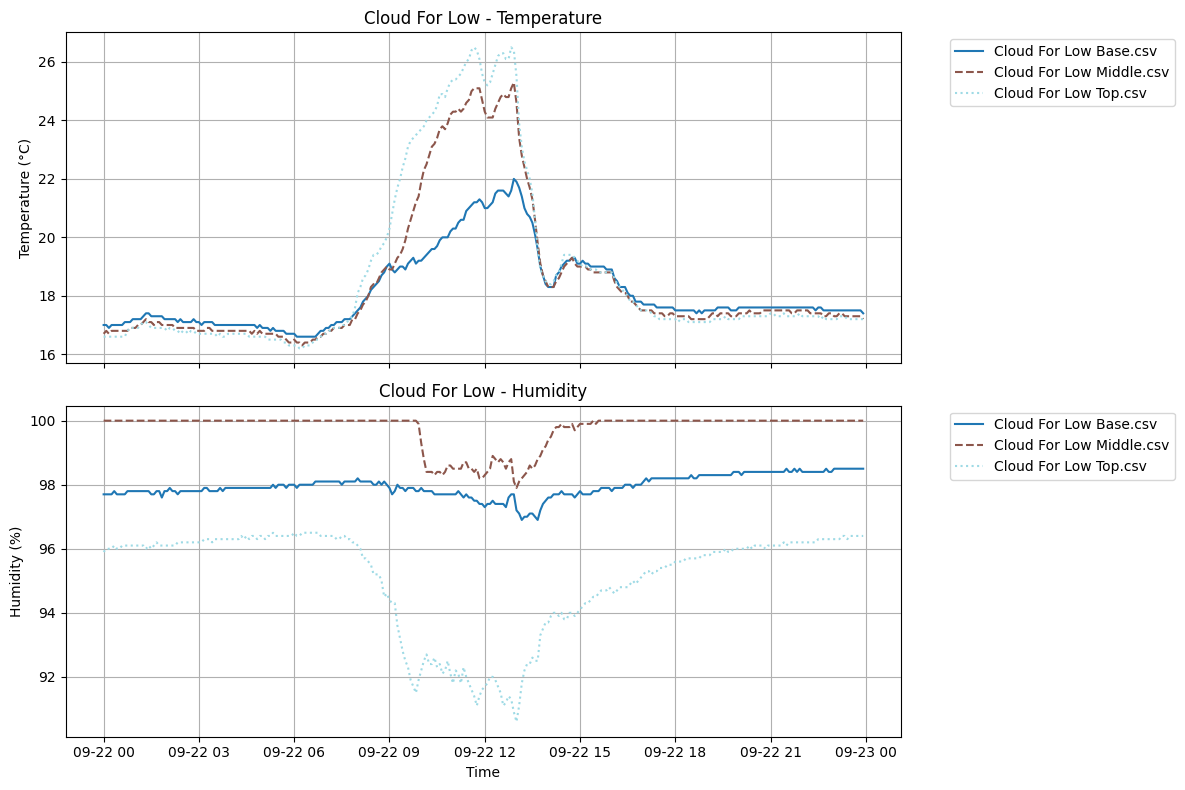

C:\Users\laank\AppData\Local\Temp\ipykernel_23148\3484153356.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(files))  # colorblind-friendly


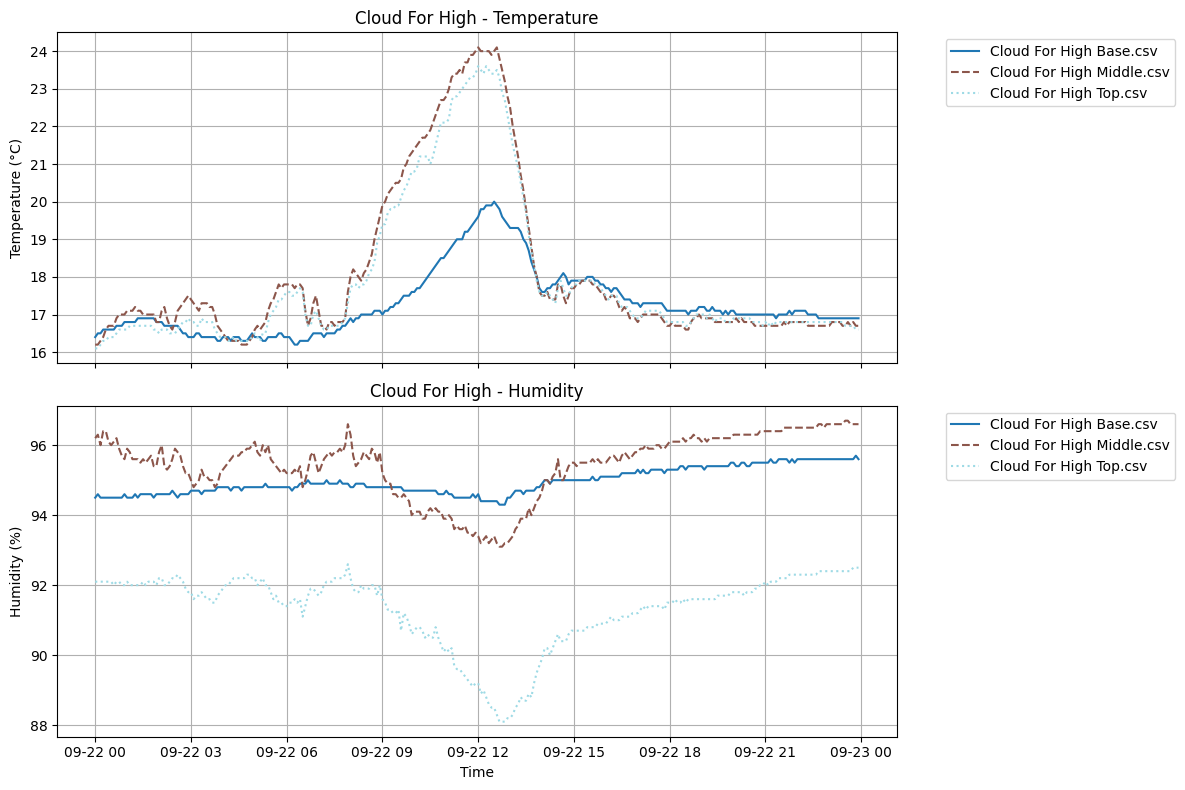

C:\Users\laank\AppData\Local\Temp\ipykernel_23148\3484153356.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(files))  # colorblind-friendly


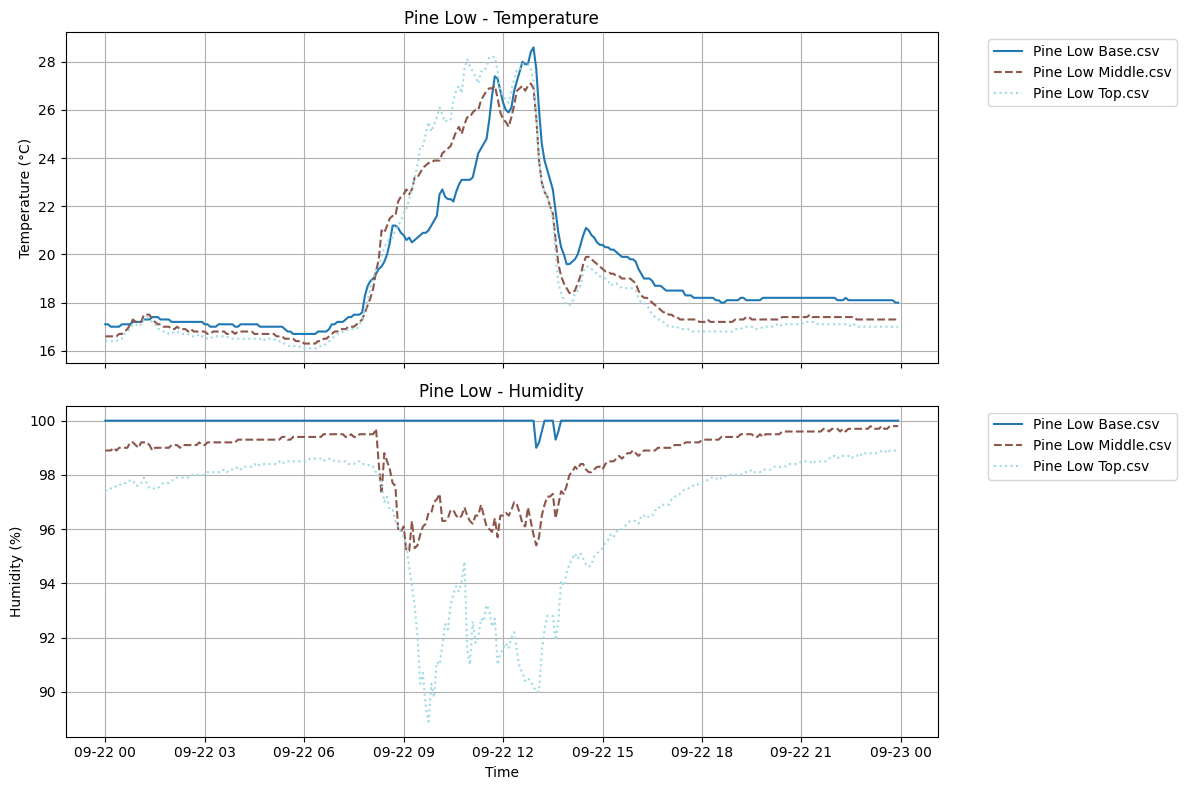

C:\Users\laank\AppData\Local\Temp\ipykernel_23148\3484153356.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(files))  # colorblind-friendly


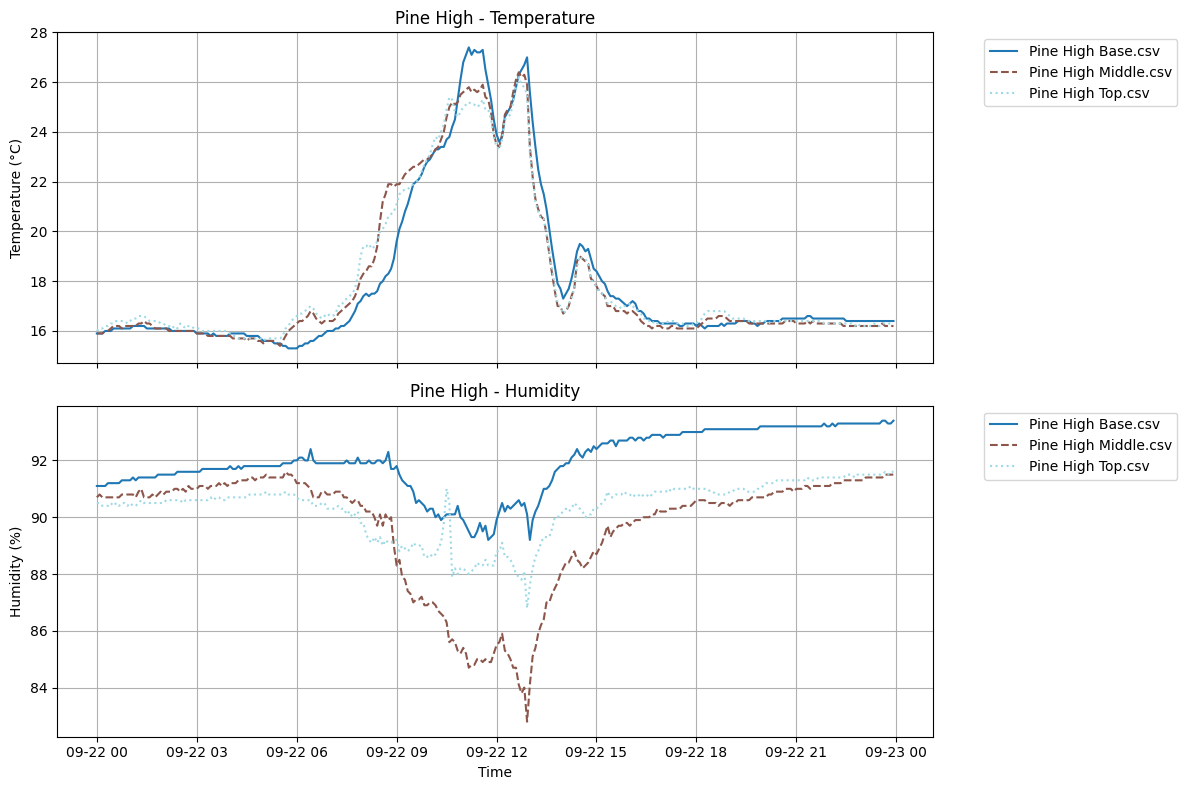

C:\Users\laank\AppData\Local\Temp\ipykernel_23148\3484153356.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(files))  # colorblind-friendly


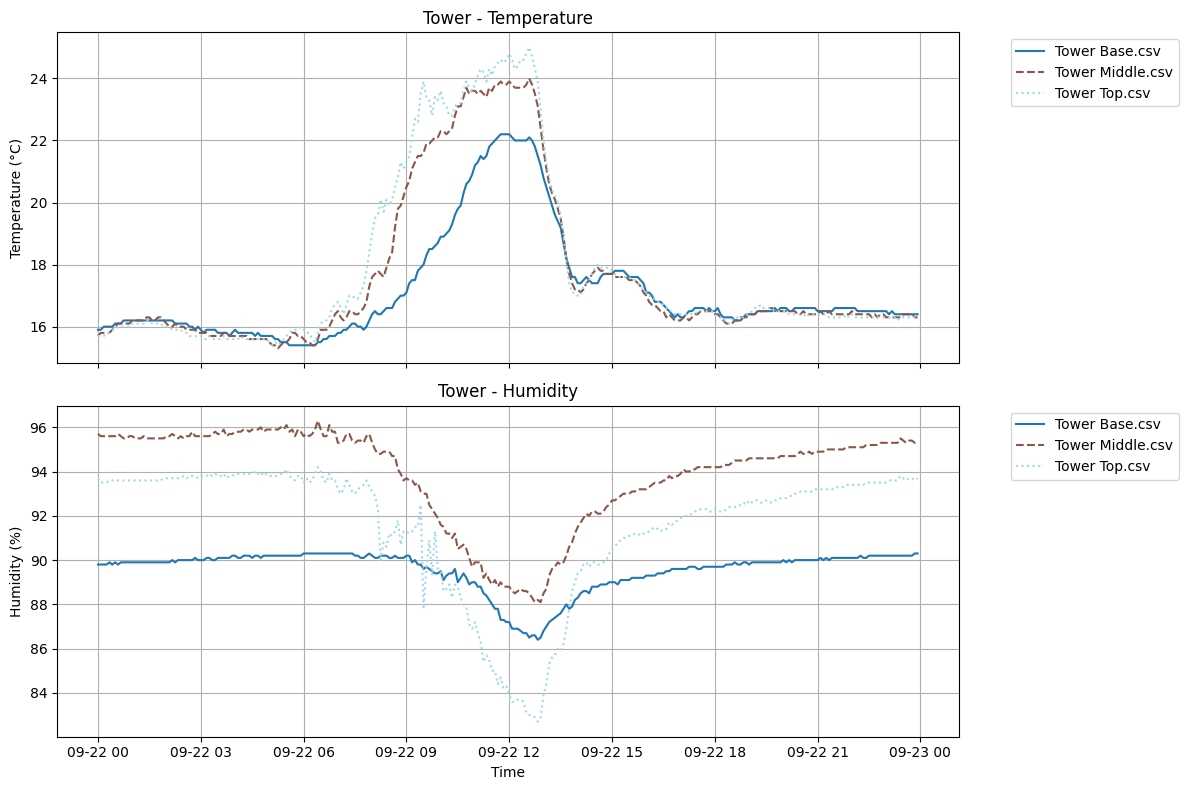

C:\Users\laank\AppData\Local\Temp\ipykernel_23148\3484153356.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(files))  # colorblind-friendly


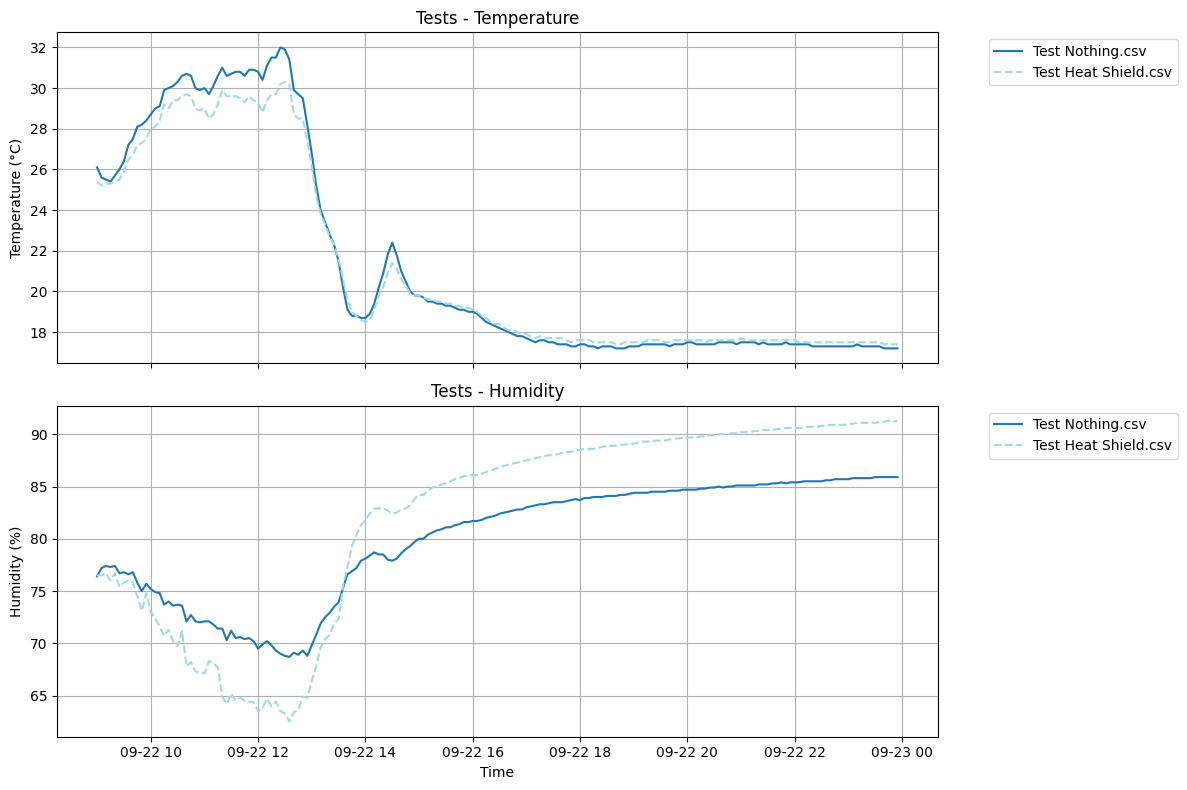

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- Group your files ---
groups = {
    "Cloud For Low": ["Cloud For Low Base.csv", "Cloud For Low Middle.csv", "Cloud For Low Top.csv"],
    "Cloud For High": ["Cloud For High Base.csv", "Cloud For High Middle.csv", "Cloud For High Top.csv"],
    "Pine Low": ["Pine Low Base.csv", "Pine Low Middle.csv", "Pine Low Top.csv"],
    "Pine High": ["Pine High Base.csv", "Pine High Middle.csv", "Pine High Top.csv"],
    "Tower": ["Tower Base.csv", "Tower Middle.csv", "Tower Top.csv"],
    "Tests": ["Test Nothing.csv", "Test Heat Shield.csv"]
}

start_date = pd.to_datetime("2025-09-22")
end_date   = pd.to_datetime("2025-09-23")

# Define a list of linestyles to cycle through
linestyles = ["-", "--", ":"]

# --- Loop through groups ---
for group_name, files in groups.items():
    colors = cm.get_cmap("tab20", len(files))  # colorblind-friendly

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    for i, name in enumerate(files):
        df = pd.read_csv(
            name,
            sep=",",
            decimal=".",
            usecols=[0, 1, 2, 3, 4],
            header=None,
            names=["ID", "Date", "Time", "Temp", "Humidity"]
        )

        df["Datetime"] = pd.to_datetime(
            df["Date"].astype(str) + " " + df["Time"].astype(str),
            errors="coerce"
        )

        df = df[(df["Datetime"] >= start_date) & (df["Datetime"] <= end_date)]

        # Pick linestyle based on index (wraps around if more than 3)
        linestyle = linestyles[i % len(linestyles)]

        # Plot temperature
        axes[0].plot(df["Datetime"], df["Temp"],
                     label=name,
                     color=colors(i),
                     linestyle=linestyle)

        # Plot humidity
        axes[1].plot(df["Datetime"], df["Humidity"],
                     label=name,
                     color=colors(i),
                     linestyle=linestyle)

    # Labels and titles
    axes[0].set_title(f"{group_name} - Temperature")
    axes[0].set_ylabel("Temperature (°C)")
    axes[0].grid()
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    axes[1].set_title(f"{group_name} - Humidity")
    axes[1].set_ylabel("Humidity (%)")
    axes[1].set_xlabel("Time")
    axes[1].grid()
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()


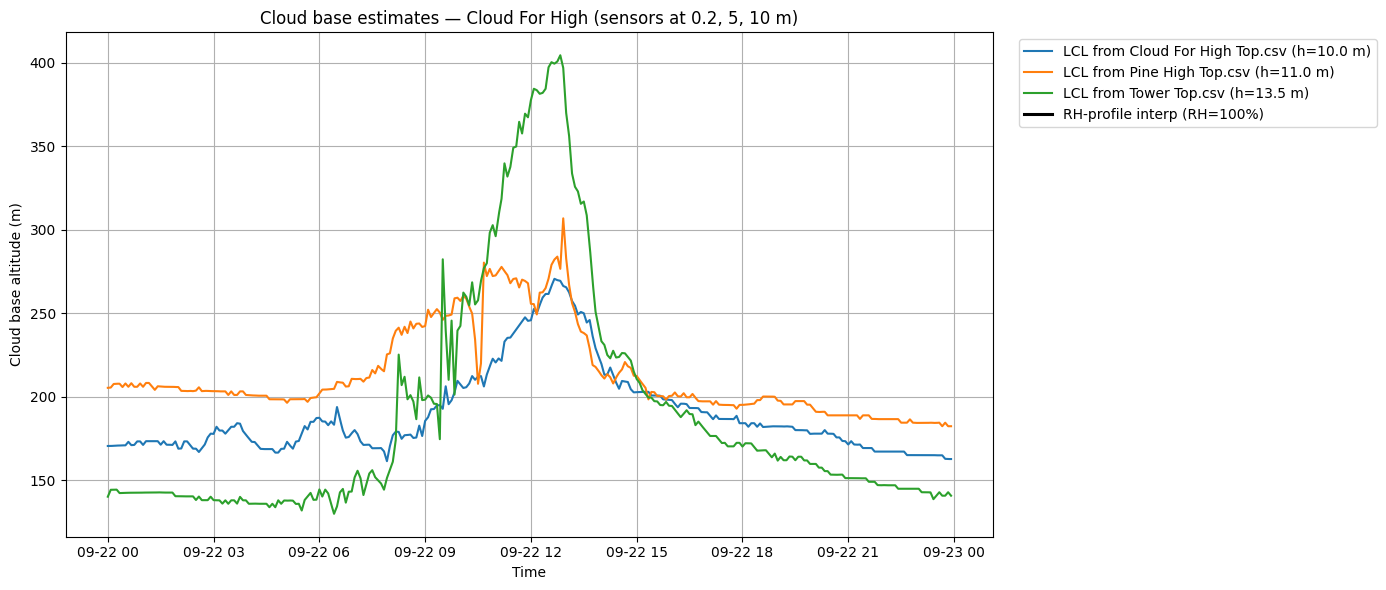

Summary (valid points count):
  LCL from Cloud For High Top.csv (height 10.0 m): 1436 valid points — median 181.3 m
  LCL from Pine High Top.csv (height 11.0 m): 1436 valid points — median 203.5 m
  LCL from Tower Top.csv (height 13.5 m): 1436 valid points — median 159.8 m
  RH-interpolated CB: 0 valid points — median nan m


C:\Users\laank\AppData\Local\Temp\ipykernel_23148\3770907779.py:152: RuntimeWarning: All-NaN slice encountered
  print(f"  RH-interpolated CB: {valid_interp} valid points — median {np.nanmedian(merged['CB_interp_m']):.1f} m")


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# filenames for the "Cloud For High" group
files = [
    "Pine High Top.csv",
    "Cloud For High Top.csv",
    "Tower Top.csv"
]

# sensor heights in meters
heights = {
    "Tower Top.csv": 13.5,
    "Cloud For High Top.csv": 10.0,
    "Pine High Top.csv": 11.0
}

start_date = pd.to_datetime("2025-09-22")
end_date   = pd.to_datetime("2025-09-23")

# --- helper functions ---
def dewpoint_magnus(T, RH):
    """Magnus approximation. T in °C, RH in % -> Td in °C"""
    a = 17.27
    b = 237.7
    alpha = (a * T) / (b + T) + np.log(np.clip(RH, 0.1, 100.0) / 100.0)
    Td = (b * alpha) / (a - alpha)
    return Td

def interp_rh100_height(rh_values, heights_arr):
    """
    Linearly interpolate height where RH==100% from rh_values at increasing heights.
    rh_values: array-like of RH% ordered by increasing heights.
    heights_arr: corresponding heights (m), monotonic increasing.
    returns: interpolated height (m) or np.nan if no crossing found.
    """
    # ensure numpy arrays
    r = np.array(rh_values, dtype=float)
    h = np.array(heights_arr, dtype=float)
    # skip if all nan
    if np.all(np.isnan(r)):
        return np.nan
    # if lowest already >=100 -> cloud at/below lowest sensor: return lowest height
    if r[0] >= 100.0:
        return h[0]
    # loop pairs and find crossing where r[i] < 100 <= r[i+1]
    for i in range(len(r)-1):
        r1, r2 = r[i], r[i+1]
        if np.isnan(r1) or np.isnan(r2):
            continue
        if (r1 < 100.0 <= r2):
            if r2 == r1:
                return h[i]
            frac = (100.0 - r1) / (r2 - r1)
            return h[i] + frac * (h[i+1] - h[i])
    # no crossing found
    return np.nan

# --- load and preprocess each file into a standardized dataframe ---
dfs = {}
for fname in files:
    df = pd.read_csv(
        fname, sep=",", decimal=".", header=None,
        usecols=[0,1,2,3,4], names=["ID","Date","Time","Temp","Humidity"]
    )
    # parse datetime
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce")
    df = df.dropna(subset=["Datetime"]).set_index("Datetime")[["Temp","Humidity"]]
    # remove obviously bad values (optional thresholds)
    df = df[(df.index >= start_date) & (df.index <= end_date)]
    df = df[(df["Temp"].between(-40, 60, inclusive="both")) & (df["Humidity"].between(0, 100, inclusive="both"))]
    dfs[fname] = df

# --- make a common time index (1-minute resolution) covering the overlap of all sensors ---
# You can change freq to '1T' (1 minute) or '30S', etc.
freq = "1min"
start = max(df.index.min() for df in dfs.values())
end   = min(df.index.max() for df in dfs.values())
if start >= end:
    # fallback to union if no overlap — use min/max across sensors
    start = min(df.index.min() for df in dfs.values())
    end   = max(df.index.max() for df in dfs.values())

common_index = pd.date_range(start=start, end=end, freq=freq)

# resample/interpolate each sensor to the common index
for fname, df in dfs.items():
    # reindex with interpolation to fill gaps
    df = df.reindex(df.index.union(common_index)).sort_index()
    df = df.interpolate(method="time").reindex(common_index)
    dfs[fname] = df

# --- compute per-sensor LCL and cloud base altitude ---
results = {}
for fname, df in dfs.items():
    T = df["Temp"].values
    RH = df["Humidity"].values
    Td = dewpoint_magnus(T, RH)
    LCL_m = 125.0 * (T - Td)               # LCL above sensor (meters)
    CloudBase_alt_m = heights[fname] + LCL_m
    out = pd.DataFrame({
        "Temp": T,
        "RH": RH,
        "Td": Td,
        "LCL_m": LCL_m,
        "CloudBase_alt_m": CloudBase_alt_m
    }, index=common_index)
    results[fname] = out

# --- create a merged frame ordered bottom->top by height ---
files_sorted = sorted(files, key=lambda f: heights[f])   # lowest -> highest
heights_sorted = [heights[f] for f in files_sorted]
rh_cols = [f"RH_{i}" for i in range(len(files_sorted))]
lcl_cols = [f"LCLalt_{i}" for i in range(len(files_sorted))]

merged = pd.DataFrame(index=common_index)
for i, f in enumerate(files_sorted):
    merged[f"Temp_{i}"] = results[f]["Temp"]
    merged[f"RH_{i}"]   = results[f]["RH"]
    merged[f"LCLalt_{i}"] = results[f]["CloudBase_alt_m"]

# --- compute RH-interpolated cloud base series ---
cb_interp = []
for idx, row in merged.iterrows():
    rh_vals = [row[f"RH_{i}"] for i in range(len(files_sorted))]
    cb_h = interp_rh100_height(rh_vals, heights_sorted)
    cb_interp.append(cb_h)
merged["CB_interp_m"] = cb_interp

# --- plotting ---
plt.figure(figsize=(14,6))
# plot LCL-based cloudbase from each sensor
for i, f in enumerate(files_sorted):
    plt.plot(merged.index, merged[f"LCLalt_{i}"], label=f"LCL from {f} (h={heights_sorted[i]} m)")
# plot RH-interpolated cloud base
plt.plot(merged.index, merged["CB_interp_m"], lw=2.2, label="RH-profile interp (RH=100%)", color="k")
plt.ylabel("Cloud base altitude (m)")
plt.xlabel("Time")
plt.title("Cloud base estimates — Cloud For High (sensors at 0.2, 5, 10 m)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- quick numeric summary ---
print("Summary (valid points count):")
for i, f in enumerate(files_sorted):
    valid = merged[f"LCLalt_{i}"].notna().sum()
    print(f"  LCL from {f} (height {heights_sorted[i]} m): {valid} valid points — median {np.nanmedian(merged[f'LCLalt_{i}']):.1f} m")
valid_interp = merged["CB_interp_m"].notna().sum()
print(f"  RH-interpolated CB: {valid_interp} valid points — median {np.nanmedian(merged['CB_interp_m']):.1f} m")


# files = [
#     "Cloud For High Base.csv",
#     "Cloud For High Middle.csv",
#     "Cloud For High Top.csv"
# ]

# # sensor heights in meters
# heights = {
#     "Cloud For High Base.csv": 0.2,
#     "Cloud For High Middle.csv": 5.0,
#     "Cloud For High Top.csv": 10.0
# }

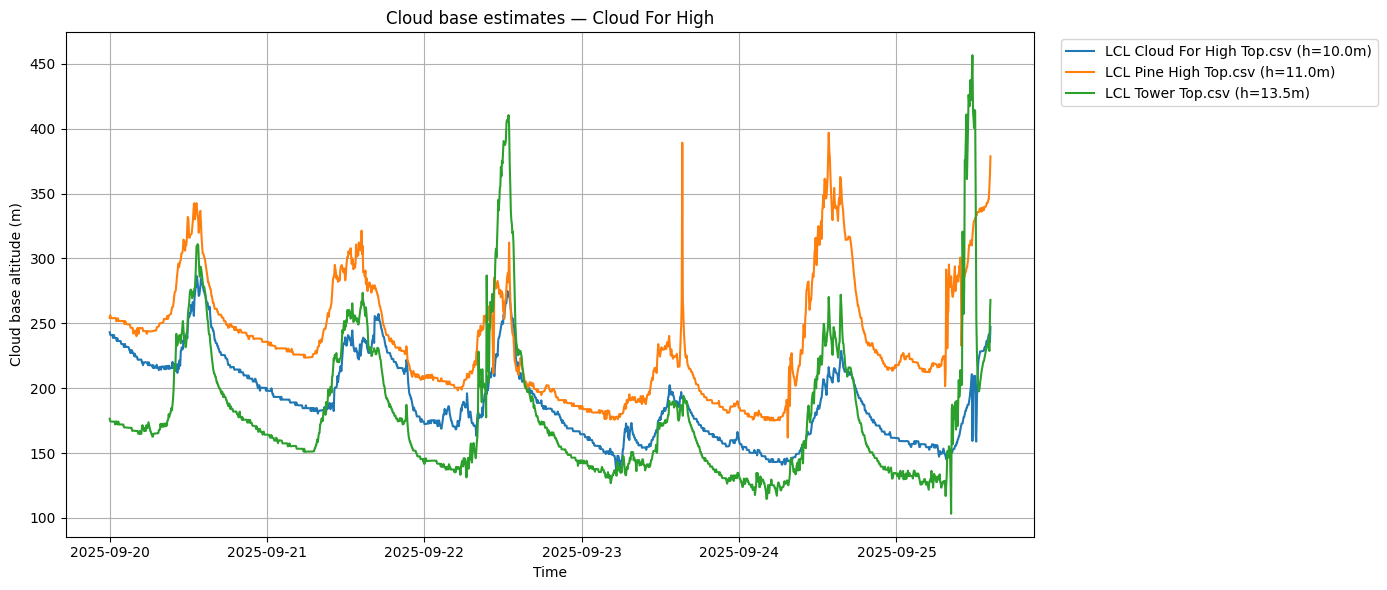

Summary (median altitudes):
  LCL Cloud For High Top.csv : 184.7 m
  LCL Pine High Top.csv : 228.3 m
  LCL Tower Top.csv : 165.2 m


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- files and heights for Cloud For High ---
files = [
    "Pine High Top.csv",
    "Cloud For High Top.csv",
    "Tower Top.csv"
]

# sensor heights in meters
heights = {
    "Tower Top.csv": 13.5,
    "Cloud For High Top.csv": 10.0,
    "Pine High Top.csv": 11.0
}

start_date = pd.to_datetime("2025-09-20")
end_date   = pd.to_datetime("2025-09-26")
freq = "1min"  # resample frequency

# --- helper functions ---
def dewpoint_magnus(T, RH):
    """Magnus approximation. T in °C, RH in % -> Td in °C"""
    a, b = 17.27, 237.7
    alpha = (a * T) / (b + T) + np.log(np.clip(RH, 0.1, 100.0) / 100.0)
    return (b * alpha) / (a - alpha)

def lcl_height_bolton(T, Td, P):
    """
    Compute LCL height (m) using Bolton (1980).
    T, Td in °C, P in Pa
    """
    Rd = 287.0   # J/kg/K
    cp = 1005.0  # J/kg/K
    g  = 9.81    # m/s^2

    # convert to Kelvin
    T_k = T + 273.15
    Td_k = Td + 273.15

    # Bolton formula for TLCL (K)
    Tlcl = 1.0 / (1.0/(Td_k - 56.0) + np.log(T_k/Td_k)/800.0) + 56.0

    # Pressure at LCL (Pa)
    Plcl = P * (Tlcl/T_k) ** (cp/Rd)

    # Hypsometric equation → height difference (m)
    Tv = (T_k + Tlcl) / 2.0   # mean virtual temp approx
    delta_z = (Rd * Tv / g) * np.log(P/Plcl)

    return delta_z

# --- load and preprocess ---
dfs = {}
for fname in files:
    df = pd.read_csv(
        fname, sep=",", decimal=".", header=None,
        usecols=[0,1,2,3,4], names=["ID","Date","Time","Temp","Humidity"]
    )
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str)+" "+df["Time"].astype(str), errors="coerce")
    df = df.dropna(subset=["Datetime"]).set_index("Datetime")[["Temp","Humidity"]]
    # filter by time range
    df = df[(df.index >= start_date) & (df.index <= end_date)]
    # filter bad values
    df = df[(df["Temp"].between(-40,60)) & (df["Humidity"].between(0,100))]
    dfs[fname] = df

# --- common time index ---
start = max(df.index.min() for df in dfs.values())
end   = min(df.index.max() for df in dfs.values())
if start >= end:  # fallback if no overlap
    start = min(df.index.min() for df in dfs.values())
    end   = max(df.index.max() for df in dfs.values())
common_index = pd.date_range(start, end, freq=freq)

# resample/interpolate
for fname, df in dfs.items():
    df = df.reindex(df.index.union(common_index)).sort_index()
    df = df.interpolate(method="time").reindex(common_index)
    dfs[fname] = df

# --- compute LCL per sensor ---
results = {}
P_surface = 85000  # Pa, assume ~850 hPa for Sierra Yalijux; replace with measurements if available
for fname, df in dfs.items():
    T, RH = df["Temp"].values, df["Humidity"].values
    Td = dewpoint_magnus(T, RH)
    LCL_m = np.array([lcl_height_bolton(t, td, P_surface) for t, td in zip(T, Td)])
    CloudBase_alt_m = heights[fname] + LCL_m
    out = pd.DataFrame({
        "Temp": T, "RH": RH, "Td": Td,
        "LCL_m": LCL_m, "CloudBase_alt_m": CloudBase_alt_m
    }, index=common_index)
    results[fname] = out

# --- merged dataframe ---
files_sorted = sorted(files, key=lambda f: heights[f])
heights_sorted = [heights[f] for f in files_sorted]
merged = pd.DataFrame(index=common_index)
for i,f in enumerate(files_sorted):
    merged[f"Temp_{i}"] = results[f]["Temp"]
    merged[f"RH_{i}"]   = results[f]["RH"]
    merged[f"LCLalt_{i}"] = results[f]["CloudBase_alt_m"]

# --- plotting ---
plt.figure(figsize=(14,6))
for i,f in enumerate(files_sorted):
    plt.plot(merged.index, merged[f"LCLalt_{i}"], label=f"LCL {f} (h={heights_sorted[i]}m)")
plt.ylabel("Cloud base altitude (m)")
plt.xlabel("Time")
plt.title("Cloud base estimates — Cloud For High")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- summary ---
print("Summary (median altitudes):")
for i,f in enumerate(files_sorted):
    print(f"  LCL {f} : {np.nanmedian(merged[f'LCLalt_{i}']):.1f} m")


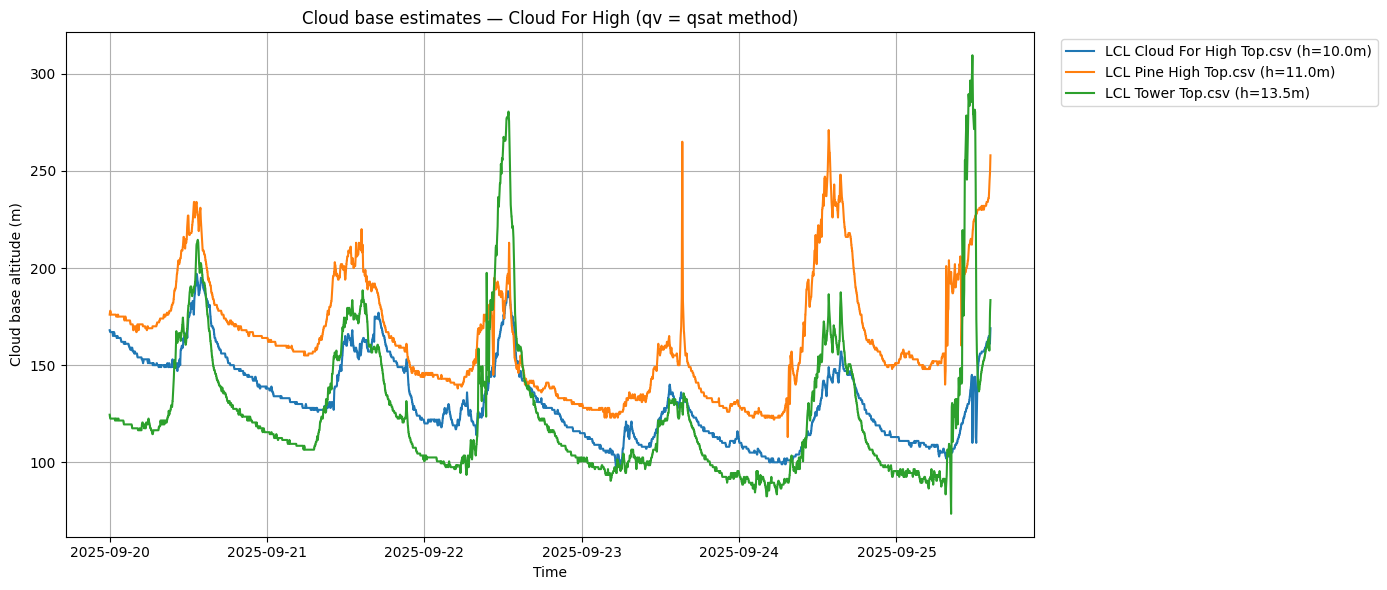

Summary (median altitudes):
  LCL Cloud For High Top.csv : 128.0 m
  LCL Pine High Top.csv : 158.0 m
  LCL Tower Top.csv : 116.5 m


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- files and heights for Cloud For High ---
files = [
    "Pine High Top.csv",
    "Cloud For High Top.csv",
    "Tower Top.csv"
]

# sensor heights in meters
heights = {
    "Tower Top.csv": 13.5,
    "Cloud For High Top.csv": 10.0,
    "Pine High Top.csv": 11.0
}

start_date = pd.to_datetime("2025-09-20")
end_date   = pd.to_datetime("2025-09-26")
freq = "1min"  # resample frequency

# --- constants ---
Rd = 287.05   # dry air gas constant (J/kg/K)
Rv = 461.5    # water vapor gas constant (J/kg/K)
g  = 9.81     # m/s2
dtdz = -9.8/1000  # dry adiabatic lapse rate (K/m)
p_surface = 85000  # Pa (approx Sierra Yalijux, ~850 hPa)

# --- helper functions ---
def esat(Tk):
    """Saturation vapor pressure (Pa), T in K"""
    return 610.78 * np.exp(17.2694 * (Tk - 273.16) / (Tk - 35.86))

def qsat(Tk, p):
    """Saturation specific humidity"""
    e = esat(Tk)
    return Rd * e / (Rv * (p - e) + Rd * e)

def lcl_from_qv(T0, RH0, p0=p_surface, zmax=4000, dz=1):
    """
    Find LCL height by intersecting constant qv with qsat(z).
    T0 in °C, RH0 in %, p0 in Pa
    """
    T0k = T0 + 273.15
    e0 = (RH0/100.0) * esat(T0k)
    w = (0.622 * e0) / (p0 - e0)
    qv = w / (1 + w)

    z = np.arange(0, zmax+dz, dz)
    T_profile = T0k + dtdz * z
    a = 1 + (dtdz * z) / T0k
    b = -g / (Rd * dtdz)
    p_profile = p0 * a**-b

    qsat_profile = qsat(T_profile, p_profile)

    # Find where qv crosses qsat
    diff = np.abs(qsat_profile - qv)
    iz = np.argmin(diff)
    return z[iz]  # meters above sensor

# --- load and preprocess ---
dfs = {}
for fname in files:
    df = pd.read_csv(
        fname, sep=",", decimal=".", header=None,
        usecols=[0,1,2,3,4], names=["ID","Date","Time","Temp","Humidity"]
    )
    df["Datetime"] = pd.to_datetime(
        df["Date"].astype(str)+" "+df["Time"].astype(str), errors="coerce"
    )
    df = df.dropna(subset=["Datetime"]).set_index("Datetime")[["Temp","Humidity"]]
    df = df[(df.index >= start_date) & (df.index <= end_date)]
    df = df[(df["Temp"].between(-40,60)) & (df["Humidity"].between(0,100))]
    dfs[fname] = df

# --- common time index ---
start = max(df.index.min() for df in dfs.values())
end   = min(df.index.max() for df in dfs.values())
if start >= end:
    start = min(df.index.min() for df in dfs.values())
    end   = max(df.index.max() for df in dfs.values())
common_index = pd.date_range(start, end, freq=freq)

for fname, df in dfs.items():
    df = df.reindex(df.index.union(common_index)).sort_index()
    df = df.interpolate(method="time").reindex(common_index)
    dfs[fname] = df

# --- compute LCL via qv = qsat method ---
results = {}
for fname, df in dfs.items():
    T, RH = df["Temp"].values, df["Humidity"].values
    LCL_list = [lcl_from_qv(t, rh, p_surface) for t, rh in zip(T, RH)]
    LCL_arr = np.array(LCL_list)
    CloudBase_alt_m = heights[fname] + LCL_arr
    out = pd.DataFrame({
        "Temp": T, "RH": RH,
        "LCL_m": LCL_arr,
        "CloudBase_alt_m": CloudBase_alt_m
    }, index=common_index)
    results[fname] = out

# --- merged dataframe ---
files_sorted = sorted(files, key=lambda f: heights[f])
heights_sorted = [heights[f] for f in files_sorted]
merged = pd.DataFrame(index=common_index)
for i,f in enumerate(files_sorted):
    merged[f"Temp_{i}"] = results[f]["Temp"]
    merged[f"RH_{i}"]   = results[f]["RH"]
    merged[f"LCLalt_{i}"] = results[f]["CloudBase_alt_m"]

# --- plotting ---
plt.figure(figsize=(14,6))
for i,f in enumerate(files_sorted):
    plt.plot(merged.index, merged[f"LCLalt_{i}"], label=f"LCL {f} (h={heights_sorted[i]}m)")
plt.ylabel("Cloud base altitude (m)")
plt.xlabel("Time")
plt.title("Cloud base estimates — Cloud For High (qv = qsat method)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- summary ---
print("Summary (median altitudes):")
for i,f in enumerate(files_sorted):
    print(f"  LCL {f} : {np.nanmedian(merged[f'LCLalt_{i}']):.1f} m")
